# import experimental data

In [1]:
from utils import *
NOTEBOOK_ID = '07'

# go term analysis

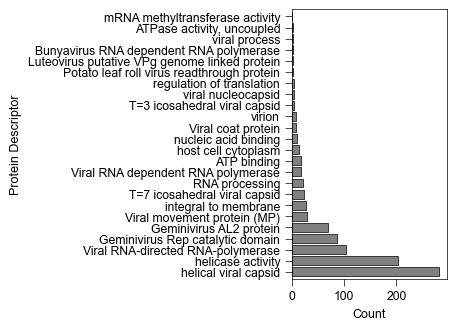

In [2]:
data_df = pd.read_csv(f'{ANALYSIS_DIR}/experimental_data_fitted.csv')
tiles_df = pd.read_csv(f'{TILE_DIR}/viral_tiles.csv')
library_df = pd.read_csv(f'{LIBRARY_DIR}/viral_library.csv')
protein_df = pd.read_csv(f'{TILE_DIR}/viral_proteins_clustered90.csv')

MAKE_FASTA = False
if MAKE_FASTA:
    with open(f'{ANALYSIS_DIR}/viral_proteins.faa','w') as out_file:
        for _,row in protein_df.iterrows():
            out_file.write(f'>{row["description"]}\n{row["aa_seq"]}\n')
    with open(f'{ANALYSIS_DIR}/viral_tiles.faa','w') as out_file:
        for _,row in tiles_df.iterrows():
            out_file.write(f'>{row["tile_ID"]}\n{row["tile"]}\n')
    with open(f'{ANALYSIS_DIR}/viral_library.faa','w') as out_file:
        for _,row in library_df.iterrows():
            out_file.write(f'>{row["tile_ID"]}\n{row["aa_seq"]}\n')

cols = ['query','seed_ortholog','evalue','score','eggNOG_OGs','max_annot_lvl','COG_category','Description','Preferred_name','GOs','EC','KEGG_ko','KEGG_Pathway','KEGG_Module','KEGG_Reaction','KEGG_rclass','BRITE','KEGG_TC','CAZy','BiGG_Reaction','PFAMs']
eggnog_df = pd.read_csv(f'{ANALYSIS_DIR}/eggnog_mapper_results.tsv',sep='\t',comment='#',names=cols)
eggnog_df = eggnog_df.replace('-',np.nan).dropna(axis=1, how='all')
merged_df = library_df.merge(eggnog_df,left_on='protein_ID',right_on='query')
background_df = eggnog_df[~eggnog_df['query'].isin(library_df['protein_ID'])]
tmp_df = merged_df.groupby('Description')['library_ID'].count().reset_index().sort_values('library_ID')

plt.figure(figsize=(2,3.5))
g = sns.barplot(data=tmp_df,x='library_ID',y='Description',color='grey',edgecolor='black',linewidth=0.5)
g.set(xlabel='Count',ylabel='Protein Descriptor',ymargin=0.01);

if SAVE_FIGURES:
    plt.savefig(f'{FIGURE_DIR}/{NOTEBOOK_ID}-go_terms_overall.svg',**FIG_PARAMS)

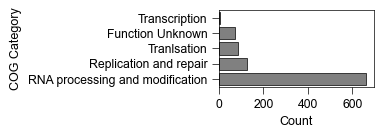

In [3]:
tmp_df = merged_df.groupby('COG_category')['library_ID'].count().reset_index().sort_values('library_ID')
tmp_df['COG_category'] = tmp_df['COG_category'].map({'A':'RNA processing and modification',
'J':'Tranlsation',
'K':'Transcription',
'L':'Replication and repair',
'S':'Function Unknown'})

plt.figure(figsize=(2,1))
g = sns.barplot(data=tmp_df,y='COG_category',x='library_ID',color='grey',edgecolor='black',linewidth=0.5)
g.set(xlabel='Count',ylabel='COG Category',ymargin=0.025)
if SAVE_FIGURES:
    plt.savefig(f'{FIGURE_DIR}/{NOTEBOOK_ID}-go_terms_overall_category.svg',**FIG_PARAMS)

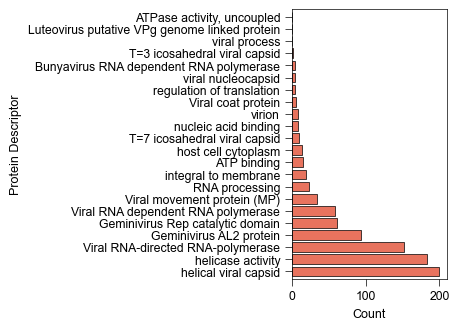

In [4]:
activator_df = data_df.query('is_activator == True')
tmp_df = activator_df.merge(eggnog_df,left_on='protein_id',right_on='query')
tmp_df = tmp_df.groupby('Description')['tile_ID'].count().reset_index().sort_values('tile_ID')

plt.figure(figsize=(2,3.5))
g = sns.barplot(data=tmp_df.sort_values('tile_ID'),x='tile_ID',y='Description',color='tomato',edgecolor='black',linewidth=0.5)
g.set(xlabel='Count',ylabel='Protein Descriptor',ymargin=0.01)

if SAVE_FIGURES:
    plt.savefig(f'{FIGURE_DIR}/{NOTEBOOK_ID}-go_terms_activators.svg',**FIG_PARAMS)

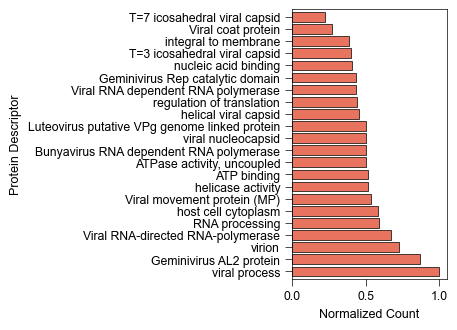

In [5]:
background_df = data_df.merge(eggnog_df,left_on='protein_id',right_on='query').groupby('Description')['tile_ID'].count()
tmp_df = activator_df.merge(eggnog_df,left_on='protein_id',right_on='query')
tmp_df = tmp_df.groupby('Description')['tile_ID'].count()
tmp_df = (tmp_df / background_df).dropna().reset_index()

plt.figure(figsize=(2,3.5))
g = sns.barplot(data=tmp_df.sort_values('tile_ID'),x='tile_ID',y='Description',color='tomato',edgecolor='black',linewidth=0.5)
g.set(xlabel='Normalized Count',ylabel='Protein Descriptor',ymargin=0.01)

if SAVE_FIGURES:
    plt.savefig(f'{FIGURE_DIR}/{NOTEBOOK_ID}-go_terms_activators_normalized.svg',**FIG_PARAMS)

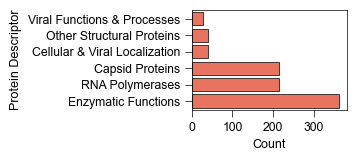

In [6]:
grouped_terms = {
    'ATP binding': 'Enzymatic Functions',
    'Bunyavirus RNA dependent RNA polymerase': 'RNA Polymerases',
    'Geminivirus AL2 protein': 'Enzymatic Functions',
    'Geminivirus Rep catalytic domain': 'Enzymatic Functions',
    'RNA processing': 'Viral Functions & Processes',
    'T=7 icosahedral viral capsid': 'Capsid Proteins',
    'Viral RNA dependent RNA polymerase': 'RNA Polymerases',
    'Viral RNA-directed RNA-polymerase': 'RNA Polymerases',
    'Viral coat protein': 'Other Structural Proteins',
    'Viral movement protein (MP)': 'Other Structural Proteins',
    'helical viral capsid': 'Capsid Proteins',
    'helicase activity': 'Enzymatic Functions',
    'host cell cytoplasm': 'Cellular & Viral Localization',
    'integral to membrane': 'Cellular & Viral Localization',
    'nucleic acid binding': 'Enzymatic Functions',
    'regulation of translation': 'Viral Functions & Processes',
    'viral nucleocapsid': 'Capsid Proteins',
    'virion': 'Cellular & Viral Localization'
}

tmp_df = activator_df.merge(eggnog_df,left_on='protein_id',right_on='query')
tmp_df['grouped_description'] = tmp_df['Description'].map(grouped_terms)
tmp_df = tmp_df.groupby('grouped_description')['tile_ID'].count().reset_index()

plt.figure(figsize=(2,1.3))
g = sns.barplot(data=tmp_df.sort_values('tile_ID'),x='tile_ID',y='grouped_description',color='tomato',edgecolor='black',linewidth=0.5)
g.set(xlabel='Count',ylabel='Protein Descriptor',ymargin=0.025)

if SAVE_FIGURES:
    plt.savefig(f'{FIGURE_DIR}/{NOTEBOOK_ID}-go_terms_activators_aggregated.svg',**FIG_PARAMS)

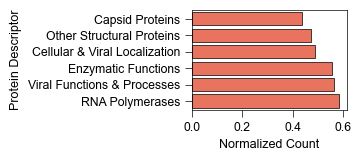

In [7]:
background_df = data_df.merge(eggnog_df,left_on='protein_id',right_on='query')
background_df['grouped_description'] = background_df['Description'].map(grouped_terms)
background_df = background_df.groupby('grouped_description')['tile_ID'].count()

tmp_df = activator_df.merge(eggnog_df,left_on='protein_id',right_on='query')
tmp_df['grouped_description'] = tmp_df['Description'].map(grouped_terms)
tmp_df = tmp_df.groupby('grouped_description')['tile_ID'].count()
tmp_df = (tmp_df / background_df).reset_index()

plt.figure(figsize=(2,1.3))
g = sns.barplot(data=tmp_df.sort_values('tile_ID'),x='tile_ID',y='grouped_description',color='tomato',edgecolor='black',linewidth=0.5)
g.set(xlabel='Normalized Count',ylabel='Protein Descriptor',ymargin=0.025)

if SAVE_FIGURES:
    plt.savefig(f'{FIGURE_DIR}/{NOTEBOOK_ID}-go_terms_activators_aggregated_normalized.svg',**FIG_PARAMS)